In [9]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

In [10]:
d1 = QuantumRegister(1, 'D1')
d2 = QuantumRegister(1, 'D2')
d3 = QuantumRegister(1, 'D3')
d4 = QuantumRegister(1, 'D4')

x1 = QuantumRegister(1, 'X1')
x2 = QuantumRegister(1, 'X2')

z1 = QuantumRegister(1, 'Z1')
z2 = QuantumRegister(1, 'Z2')

mx = ClassicalRegister(2, 'MX')
mz = ClassicalRegister(2, 'MZ')

In [11]:
circuit = QuantumCircuit(d1,d2,d3,d4,x1,x2,z1,z2, mx, mz)

In [12]:
# --- Initial Basis Prep ---
for qubit in [d2,d3,x1,x2,z1,z2]:
    circuit.h(qubit)
circuit.barrier()

# --- Round 1 ---
circuit.cz(d1,z1)
circuit.cz(d4,z2)
circuit.cz(x1,d2)
circuit.cz(x2,d3)
circuit.barrier()

# --- Round 2 ---
circuit.h(d2)
circuit.h(d3)
circuit.barrier()

circuit.cz(d2,z2)
circuit.cz(d3,z1)
circuit.barrier()

circuit.h(d1)
circuit.h(d3)
circuit.barrier()

circuit.cz(x1,d1)
circuit.cz(x2,d4)
circuit.barrier()

# --- Round 3 ---
circuit.cz(d2,z1)
circuit.cz(d3,z2)
circuit.cz(x1,d4)
circuit.barrier()

circuit.h(d4)
circuit.barrier()

circuit.cz(x2,d1)
circuit.barrier()

for qubit in [d1,d2,d3]:
    circuit.h(qubit)
circuit.barrier()

# --- Round 4 ---
circuit.cz(d1,z2)
circuit.cz(d4,z1)
circuit.cz(x1,d3)
circuit.cz(x2,d2)
circuit.barrier()

# --- Return to Computational Basis ---
for qubit in [d2,d3,x1,x2,z1,z2]:
    circuit.h(qubit)
circuit.barrier()

# --- Measurement ---
circuit.measure(x1, mx[0])
circuit.measure(x2, mx[1])
circuit.measure(z1, mz[0])
circuit.measure(z2, mz[1])
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=8, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "D1"), index=0>, <Qubit register=(1, "D2"), index=0>, <Qubit register=(1, "D3"), index=0>, <Qubit register=(1, "D4"), index=0>, <Qubit register=(1, "X1"), index=0>, <Qubit register=(1, "X2"), index=0>, <Qubit register=(1, "Z1"), index=0>, <Qubit register=(1, "Z2"), index=0>), clbits=())

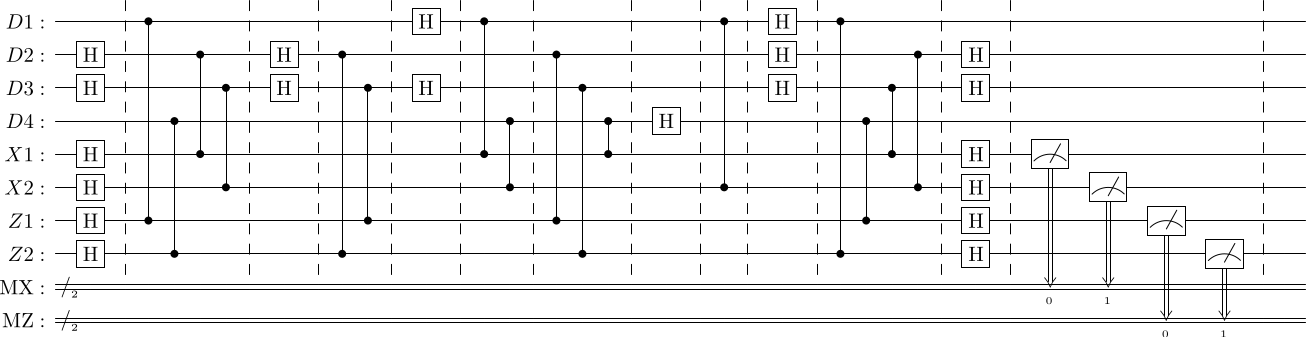

In [13]:
circuit.draw(output="latex", filename="qiskit_cz.png")

In [27]:
# Get the count of each operation
op_counts = circuit.count_ops()
print("Operation Counts")

for op in op_counts.keys():
    if op != "barrier":
        print(f"{op}: {op_counts[op]}")

Operation Counts
h: 20
cz: 16
measure: 4
